In [14]:
from matplotlib import pyplot as plt
from matplotlib import dates as mpl_dates
import plotly.graph_objects as go
from tqdm import tqdm
import yfinance as yf
import pandas as pd
import numpy as np
import os
import pandas_ta as ta
import sys
import seaborn as sns

sys.path.append('../utils')

In [15]:
if os.path.exists("data.csv"):
    df = pd.read_csv("data.csv", index_col=0)
else:
    gold_ticker = yf.Ticker("GC=F")
    df = gold_ticker.history(period="max", interval='5m')
    df.to_csv("data.csv")

df.index = pd.to_datetime(df.index, utc=True)

df.drop(columns=['Volume', 'Dividends', 'Stock Splits'], inplace=True)

# display(df.shape)
# display(df.head(3))

- Indicators

In [16]:
df["EMA_slow"] = ta.ema(df.Close, length=50)
df["EMA_fast"] = ta.ema(df.Close, length=21)
df['ATR'] = ta.atr(df.High, df.Low, df.Close, length=7)
bb = ta.bbands(df.Close, length=21, std=3)

bb = bb[[bb.columns[0], bb.columns[1], bb.columns[2]]]

bb.columns = ['bb-lower', 'bb-mid', 'bb-upper']

df=df.join(bb)

df.dropna(inplace=True)

In [17]:
length, _ = df.shape

df['Order'] = [i for i in range(1, length + 1)]

In [18]:
TREND = {
    'BULLISH': 1,
    'BEARISH': -1,
    'UNKNOWN': 0
}

def detect_trend(current_candle, num_of_back_candels):
    _start = max(0, current_candle - num_of_back_candels)
    _end = current_candle
    previous_candels = df.iloc[_start:_end]

    if all(previous_candels["EMA_fast"] < previous_candels["EMA_slow"]):
        return TREND['BEARISH']
    elif all(previous_candels["EMA_fast"] > previous_candels["EMA_slow"]):
        return TREND['BULLISH']
    else:
        return TREND['UNKNOWN']

tqdm.pandas()
df['Trend'] = df.progress_apply(lambda candel: detect_trend(int(candel.Order), 7) , axis=1)

100%|██████████| 11612/11612 [00:03<00:00, 3256.44it/s]


In [19]:
SIGNALS = {
    'BUY': 1,
    'SELL': -1,
    'CASH': 0
}

buy_filter = (df['Trend'] == TREND['BULLISH']) & (df['Low'] < df['bb-lower'])
sell_filter = (df['Trend'] == TREND['BEARISH']) & (df['High'] > df['bb-upper'])

df['Signal'] = SIGNALS['CASH']
df.loc[buy_filter, 'Signal'] = SIGNALS['BUY']
df.loc[sell_filter, 'Signal'] = SIGNALS['SELL']

# df[df['Signal'] != 0]

In [20]:
def remove_stacked_positions(current_candle):
    if current_candle > 2:
        if df.iloc[current_candle].Signal != 0:
            if df.iloc[current_candle].Signal == df.iloc[current_candle - 1].Signal: return 1
    return 0

tqdm.pandas()
df['Anti-position'] = df.progress_apply(lambda candel: remove_stacked_positions(int(candel.Order - 1)) , axis=1)

df.loc[df['Anti-position'] != 0, 'Signal'] = SIGNALS['CASH']

100%|██████████| 11612/11612 [00:01<00:00, 9077.52it/s]


In [32]:
def point_positions(x):
    if x['Signal'] == SIGNALS['BUY']:
        return x['Low']-1e+1
    elif x['Signal'] == SIGNALS['SELL']:
        return x['High']+1e+1
    else:
        return np.nan

df['point_positions'] = df.apply(lambda candel: point_positions(candel), axis=1)

- Preview

In [33]:
_start=100
ex_df = df[_start:_start+2000]
#ex_df.reset_index(inplace=True)
fig = go.Figure(data=[go.Candlestick(x=ex_df.index, open=ex_df['Open'], high=ex_df['High'], low=ex_df['Low'], close=ex_df['Close']),

                go.Scatter(x=ex_df.index, y=ex_df['bb-lower'], line=dict(color='green', width=1), name="BBL"),
                go.Scatter(x=ex_df.index, y=ex_df['bb-upper'], line=dict(color='green', width=1), name="BBU"),
                go.Scatter(x=ex_df.index, y=ex_df['EMA_fast'], line=dict(color='black', width=1), name="EMA_fast"),
                go.Scatter(x=ex_df.index, y=ex_df['EMA_slow'], line=dict(color='blue', width=1), name="EMA_slow")])

fig.add_scatter(x=ex_df.index, y=ex_df['point_positions'], mode="markers", marker=dict(size=5, color="MediumPurple"), name="entry")

fig.update_layout(autosize=False ,width=1600 ,height=800)

fig.show()

## **Strategy** 

In [23]:
from trade import Trade

df['Position'] = 0
df['Entry_Price'] = 0.0
df['Exit_Price'] = 0.0
df['PnL'] = 0.0

# Simulate the strategy with SL/TP
trade = Trade()

def exit_trade(idx, is_win: bool):
    df.loc[idx, 'Exit_Price'] = trade.tp if is_win else trade.sl
    pnl = trade.rrr if is_win else -1
    df.loc[idx, ['PnL', 'Position']] = [pnl, SIGNALS['BUY' if trade.is_buy else 'SELL']]
    return True

def is_buy_sl(idx):
    if df.loc[idx, 'Low'] <= trade.sl: return exit_trade(idx, False)
    return False

def is_buy_tp(idx, source='High'):
    if df.loc[idx, source] > trade.tp: return exit_trade(idx, True)
    return False

def is_sell_sl(idx):
    if df.loc[idx, 'High'] >= trade.sl: return exit_trade(idx, False)
    return False

def is_sell_tp(idx, source='Low'):
    if df.loc[idx, source] < trade.tp: return exit_trade(idx, True)
    return False

# [NB] check SL first then make sure trade is On to check TP
def fill_trade_params(_candel, idx):
    trade_signal = _candel['Signal']
    is_long = (trade_signal == SIGNALS['BUY'])
    _sl_range = _candel['ATR']
    _rrr = 1.5
    trade.On()
    trade.entry = _candel['bb-lower' if is_long else 'bb-upper']
    trade.sl = trade.entry - trade_signal * _sl_range
    trade.tp = trade.entry + trade_signal * _rrr * _sl_range
    df.loc[idx, ['Position', 'Entry_Price']] = [trade_signal, trade.entry]

    # check if sl or tp is already hit in the same candel (i)
    if is_long:
        if is_buy_sl(idx) or is_buy_tp(idx, source='Close'): trade.Off()
    else:
        if is_sell_sl(idx) or is_sell_tp(idx, source='Close'): trade.Off()

# Loop through candles and execute trades
for idx, candel in df.iterrows(): # candel for reading, i for writing
    if trade.on: 
        # Track price movement for Stop Loss or Take Profit
        if trade.is_buy: 
            if is_buy_sl(idx): trade.Off()
            elif is_buy_tp(idx, source='Close'): trade.Off()
        elif trade.is_sell:
            if is_sell_sl(idx): trade.Off()
            elif is_sell_tp(idx, source='Close'): trade.Off()
    elif candel['Signal'] != 0: # Check if there's a signal
            fill_trade_params(candel, idx)


- **Result**

In [24]:
# Calculate cumulative profit/loss
df['Cumulative_PnL'] = df['PnL'].cumsum()

# Filter rows where we had a trade exit
trades = df[df['PnL'] != 0]

# Summary statistics
total_trades = len(trades)
total_pnl = df['Cumulative_PnL'].iloc[-1]  # Total profit/loss
win_rate = win_rate =(df[df['PnL'] > 0]['PnL'].count())/(df[df['PnL'] != 0]['PnL'].count())
average_RRR = df[df['PnL'] > 0]['PnL'].mean()

expectency = (average_RRR + 1) * win_rate - 1

strategy_stats_df = pd.DataFrame(
    np.array([[
        total_trades,
        total_pnl,
        round(win_rate * 100, 2),
        average_RRR,
        expectency,
        expectency * total_trades
    ]]),
    columns=['Total Trades', 'Total Profit/Loss (RR)', 'Win rate (%)', 'Average Risk-Reward Ratio', 'Expectancy', 'Expected return'],
    index=['Metrics']
)

strategy_stats_df

,Total Trades,Total Profit/Loss (RR),Win rate (%),Average Risk-Reward Ratio,Expectancy,Expected return
Metrics,103.0,9.5,43.69,1.5,0.092233,9.5


- **PnL**

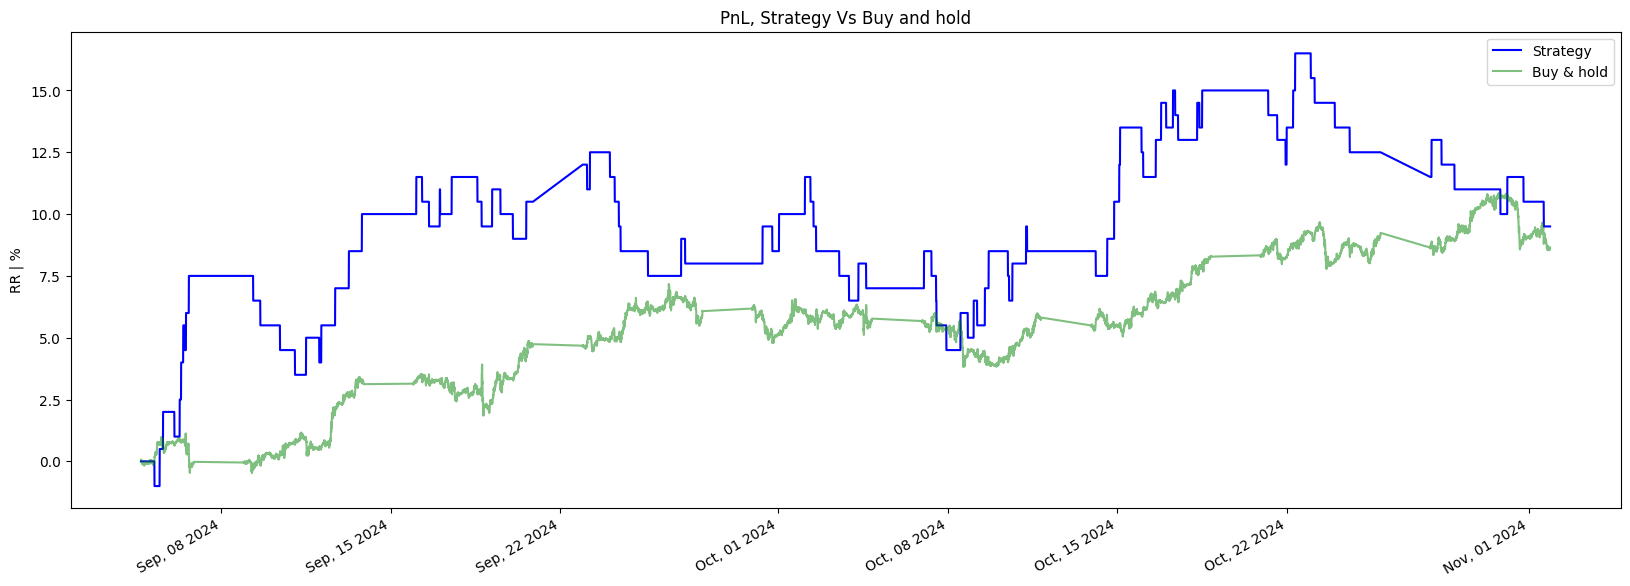

In [25]:
starting_inv_price = df['Close'].iloc[0]

FIGSIZE = {
    "WIDTH": 20,
    "HEIGHT": 7
}

# Plot the Strategy returns
df['Cumulative_PnL'].plot(
        label='Strategy', 
        figsize=(FIGSIZE['WIDTH'], 
        FIGSIZE['HEIGHT']), 
        color='blue', 
        xlabel='',
        ylabel='RR | %'
    )

(100 * (df['Close'] - starting_inv_price)/starting_inv_price).plot(
        label='Buy & hold', 
        figsize=(FIGSIZE['WIDTH'], 
        FIGSIZE['HEIGHT']), 
        color='green', 
        xlabel='',
        alpha=.5,
        ylabel='RR | %'
    )

plt.title('PnL, Strategy Vs Buy and hold')
plt.legend()

plt.gcf().autofmt_xdate()
date_format = mpl_dates.DateFormatter("%b, %d %Y")
plt.gca().xaxis.set_major_formatter(date_format)

- **PnL DrawDown**

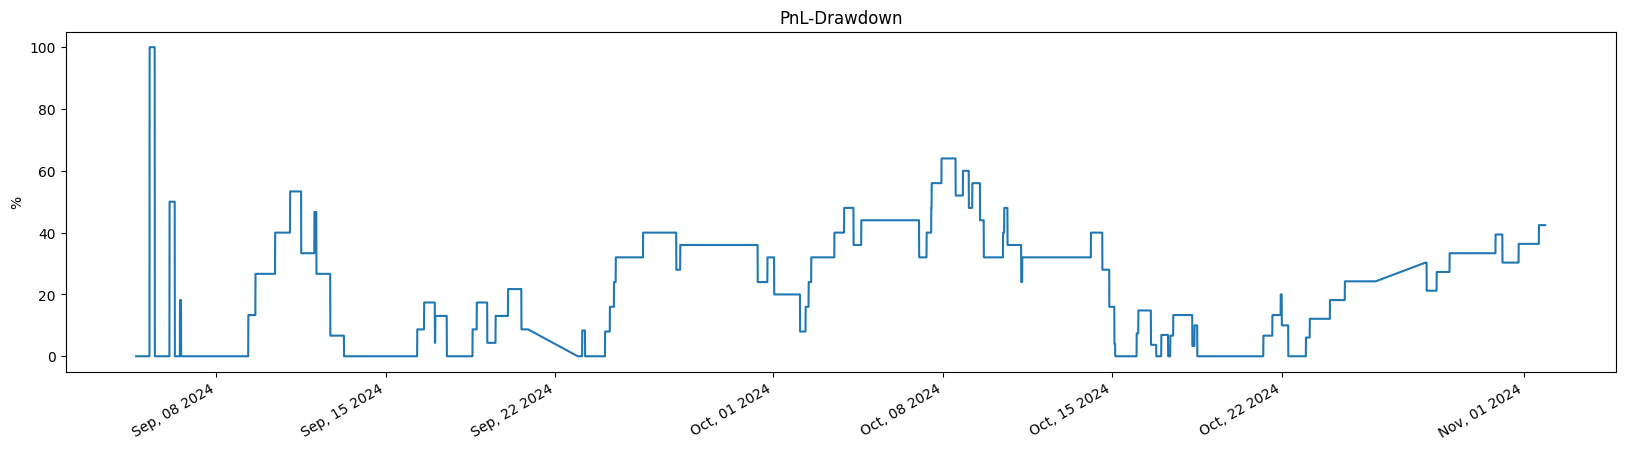

In [26]:
df['Peak'] = df['Cumulative_PnL'].cummax()

# df['Drawdown'] = (df['Peak'] - df['Cumulative_PnL']) / abs(df['Peak'])
df['Drawdown'] = np.where(df['Peak'] == 0, abs(df['Cumulative_PnL']), (df['Peak'] - df['Cumulative_PnL']) / df['Peak'])

# df['Drawdown'] = df.apply(lambda row: ((row['Peak'] - row['Cumulative_PnL']) / row['Peak']) if row['Peak'] != 0 else 0, axis=1)
# df['Drawdown'] = np.where(df['Peak'] != 0, (df['Peak'] - df['Cumulative_PnL']) / df['Peak'], 0)

(df['Drawdown'] * 100).plot(
    kind='line', 
    figsize=(FIGSIZE['WIDTH'],FIGSIZE['HEIGHT'] - 2),
    title="PnL-Drawdown",
    ylabel="%",
    xlabel=''
)

plt.gcf().autofmt_xdate()
date_format = mpl_dates.DateFormatter("%b, %d %Y")
plt.gca().xaxis.set_major_formatter(date_format)

In [27]:
print(f"Max PnL-drawdown is {round(100 * df['Drawdown'].max(), 2)} %")

Max PnL-drawdown is 100.0 %


- **Overview on positions**

<Axes: title={'center': 'Positions distribution'}, ylabel='Positions'>

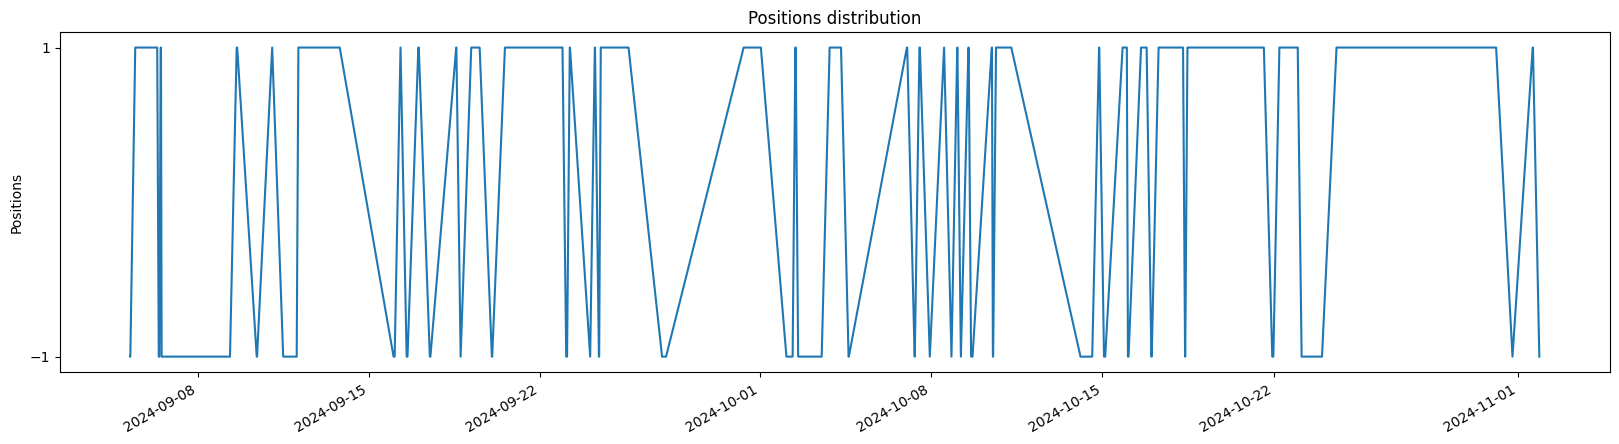

In [28]:
df[df['Position'] != 0]['Position'].plot(
    yticks=[-1, 1],
    figsize=(FIGSIZE['WIDTH'],FIGSIZE['HEIGHT'] - 2),
    title="Positions distribution",
    ylabel="Positions",
    xlabel=''
)

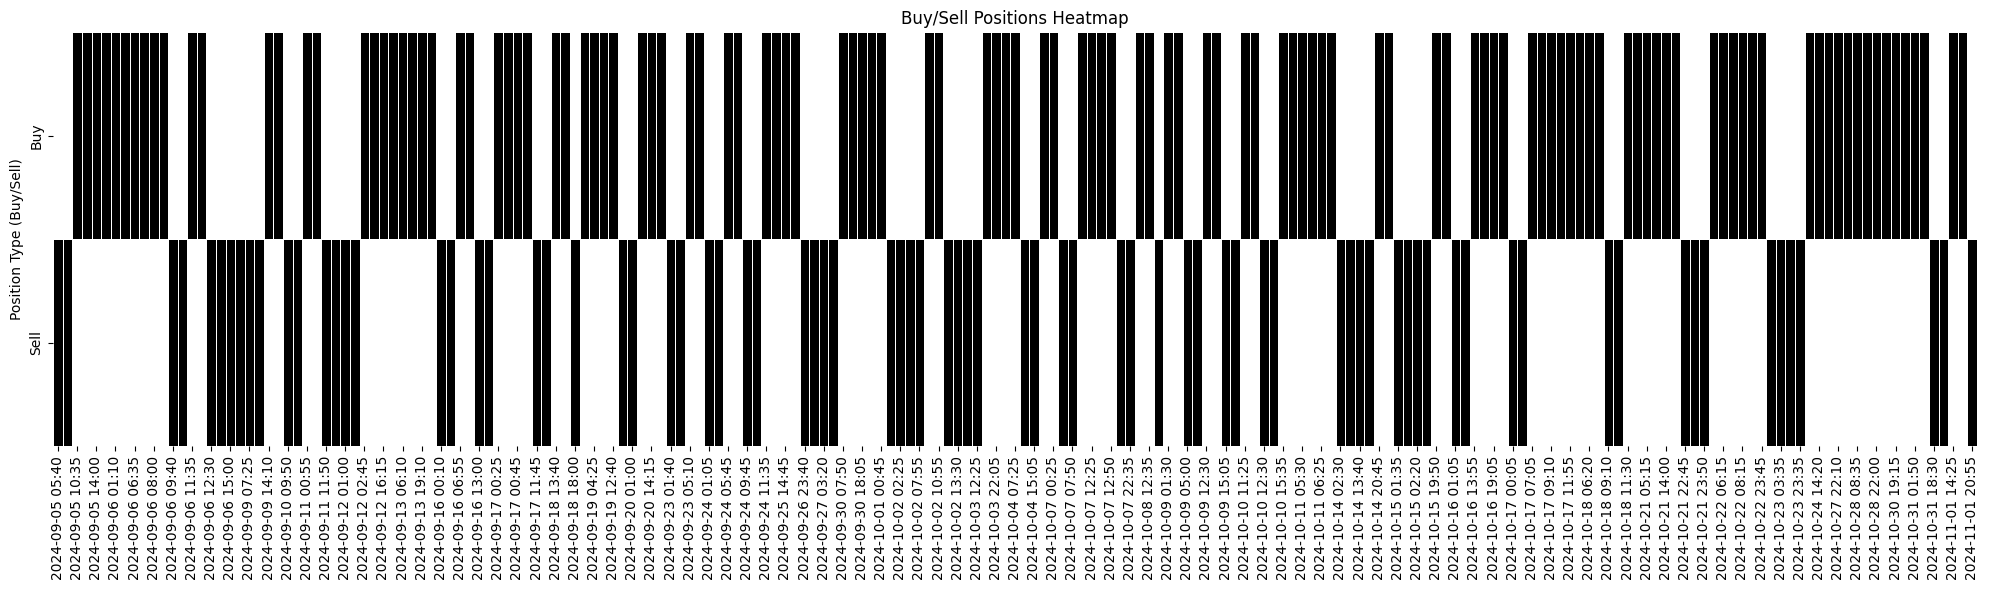

In [29]:
positions_df = pd.DataFrame(index=df.index.strftime('%Y-%m-%d %H:%M'))

positions_df['Buy'] = np.where(df['Position'] > 0, df['Position'], 0) 
positions_df['Sell'] = np.where(df['Position'] < 0, abs(df['Position']), 0) 

positions_df = positions_df.loc[(positions_df['Buy'] != 0) | (positions_df['Sell'] != 0)]

# Plot heatmap
plt.figure(figsize=(20, 6))
sns.heatmap(positions_df.T, cmap=['#FFFFFF00', 'black'], cbar=False, linewidths=0.5)

# Customize labels and title
plt.title('Buy/Sell Positions Heatmap')
plt.xlabel('')
plt.ylabel('Position Type (Buy/Sell)')

plt.tight_layout()
plt.xticks(rotation=90)
plt.show()